In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import re

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Load Data
filename = '/Users/reamchansovath/Documents/GitHub/datathon-2026/Category B Dataset/sds_datathon_gradsingapore.xlsx'
df = pd.read_excel(filename)

# Standardize Columns
rename_dict = {
    'Response ID': 'id',
    'Time Started': 'start_time',
    'Date Submitted': 'submit_time',
    'Status': 'status',
    'User Agent': 'user_agent',
    'Country': 'country',
    'Which higher education institution do you or did you study at?': 'university',
    'What is your current year of study as of 2025?': 'year',
    'What will be your highest qualification when you graduate?': 'qualification',
    'Which of the following best describes the main subject that you are studying? ': 'subject',
    'Please indicate your nationality.': 'nationality',
    'What is your gender?': 'gender',
    'Which of these statements best describes your current perception of the organisation as an employer?': 'perception',
    'Types of roles available:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_roles',
    'Career progression and development:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_career',
    'Compensation and benefits:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_comp',
    'Work-life balance and culture:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_culture',
    'Application and interview process:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_process',
    'Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  .1': 'info_other_text',
    'On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?   ': 'attractiveness',
    'Which of these factors would most motivate you to apply for a position at the organisation?  ': 'motivation',
    'Other - Write In (Required):Which of these factors would most motivate you to apply for a position at the organisation?  ': 'motivation_other'
}
df = df.rename(columns=rename_dict)
df

,id,start_time,submit_time,status,Language,SessionID,user_agent,Tags,IP Address,Longitude,...,info_roles,info_career,info_comp,info_culture,info_process,Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3),info_other_text,attractiveness,motivation,motivation_other
0,19,2025-09-02 15:03:01,2025-09-02 15:03:40,Partial,English,1756796577_68b696a123dd27.81295289,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,104.28.119.112,-97.821999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20,2025-09-02 15:15:32,2025-09-02 15:16:59,Disqualified,English,1756797328_68b699901c4cf6.89118890,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21,2025-09-02 15:18:01,2025-09-02 15:19:30,Disqualified,English,1756797478_68b69a26c5d785.44808899,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22,2025-09-03 15:25:18,2025-09-03 15:27:05,Complete,English,1756884314_68b7ed5a14f861.00788803,Mozilla/5.0 (Linux; Android 15; K) AppleWebKit...,NaN,119.234.8.156,103.839302,...,Types of roles available,Career progression and development,NaN,NaN,Application and interview process,NaN,NaN,8.0,Meaningful work impact,NaN
4,23,2025-09-03 15:34:31,2025-09-03 15:34:31,Partial,English,1756884864_68b7ef80372683.27687311,Mozilla/5.0 (iPhone; CPU iPhone OS 18_5 like M...,NaN,194.11.199.111,-77.644302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2609,2628,2025-11-13 11:04:35,2025-11-13 11:31:13,Complete,English,1763003070_69154abe22f171.48493687,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,111.65.50.67,103.754204,...,Types of roles available,NaN,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Job security,NaN
2610,2629,2025-11-13 11:16:03,2025-11-13 11:19:03,Complete,English,1763003757_69154d6da70132.86627524,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like M...,NaN,119.234.36.66,103.862801,...,NaN,Career progression and development,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Meaningful work impact,NaN
2611,2630,2025-11-13 13:02:23,2025-11-13 13:02:56,Partial,English,1763009383_6915636777bd07.70179151,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,137.132.26.63,103.763100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2612,2631,2025-11-13 14:28:12,2025-11-13 14:29:54,Disqualified,English,1763015285_69157a75b57f41.54807902,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,119.234.52.63,103.855400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# Feature Engineering
df['start_time'] = pd.to_datetime(df['start_time'])
df['submit_time'] = pd.to_datetime(df['submit_time'])
df['duration_sec'] = (df['submit_time'] - df['start_time']).dt.total_seconds()
df['is_mobile'] = df['user_agent'].str.contains('Mobile|Android|iPhone', case=False, na=False).astype(int)
df

,id,start_time,submit_time,status,Language,SessionID,user_agent,Tags,IP Address,Longitude,...,info_comp,info_culture,info_process,Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3),info_other_text,attractiveness,motivation,motivation_other,duration_sec,is_mobile
0,19,2025-09-02 15:03:01,2025-09-02 15:03:40,Partial,English,1756796577_68b696a123dd27.81295289,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,104.28.119.112,-97.821999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.0,1
1,20,2025-09-02 15:15:32,2025-09-02 15:16:59,Disqualified,English,1756797328_68b699901c4cf6.89118890,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.0,0
2,21,2025-09-02 15:18:01,2025-09-02 15:19:30,Disqualified,English,1756797478_68b69a26c5d785.44808899,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.0,0
3,22,2025-09-03 15:25:18,2025-09-03 15:27:05,Complete,English,1756884314_68b7ed5a14f861.00788803,Mozilla/5.0 (Linux; Android 15; K) AppleWebKit...,NaN,119.234.8.156,103.839302,...,NaN,NaN,Application and interview process,NaN,NaN,8.0,Meaningful work impact,NaN,107.0,1
4,23,2025-09-03 15:34:31,2025-09-03 15:34:31,Partial,English,1756884864_68b7ef80372683.27687311,Mozilla/5.0 (iPhone; CPU iPhone OS 18_5 like M...,NaN,194.11.199.111,-77.644302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2609,2628,2025-11-13 11:04:35,2025-11-13 11:31:13,Complete,English,1763003070_69154abe22f171.48493687,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,111.65.50.67,103.754204,...,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Job security,NaN,1598.0,1
2610,2629,2025-11-13 11:16:03,2025-11-13 11:19:03,Complete,English,1763003757_69154d6da70132.86627524,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like M...,NaN,119.234.36.66,103.862801,...,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Meaningful work impact,NaN,180.0,1
2611,2630,2025-11-13 13:02:23,2025-11-13 13:02:56,Partial,English,1763009383_6915636777bd07.70179151,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,137.132.26.63,103.763100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,1
2612,2631,2025-11-13 14:28:12,2025-11-13 14:29:54,Disqualified,English,1763015285_69157a75b57f41.54807902,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,119.234.52.63,103.855400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.0,1


### CATEGORY 1: Question Optimization

In [3]:
# 1.1 Logic Consistency
logic_df = pd.crosstab(df['year'], df['qualification'])

# 1.2 Correlation/Redundancy
info_cols = ['info_roles', 'info_career', 'info_comp', 'info_culture', 'info_process']
info_data = df[info_cols].notnull().astype(int)
info_corr = info_data.corr()

# 1.3 Other Field Utility
other_usage = df['info_other_text'].notnull().mean() * 100

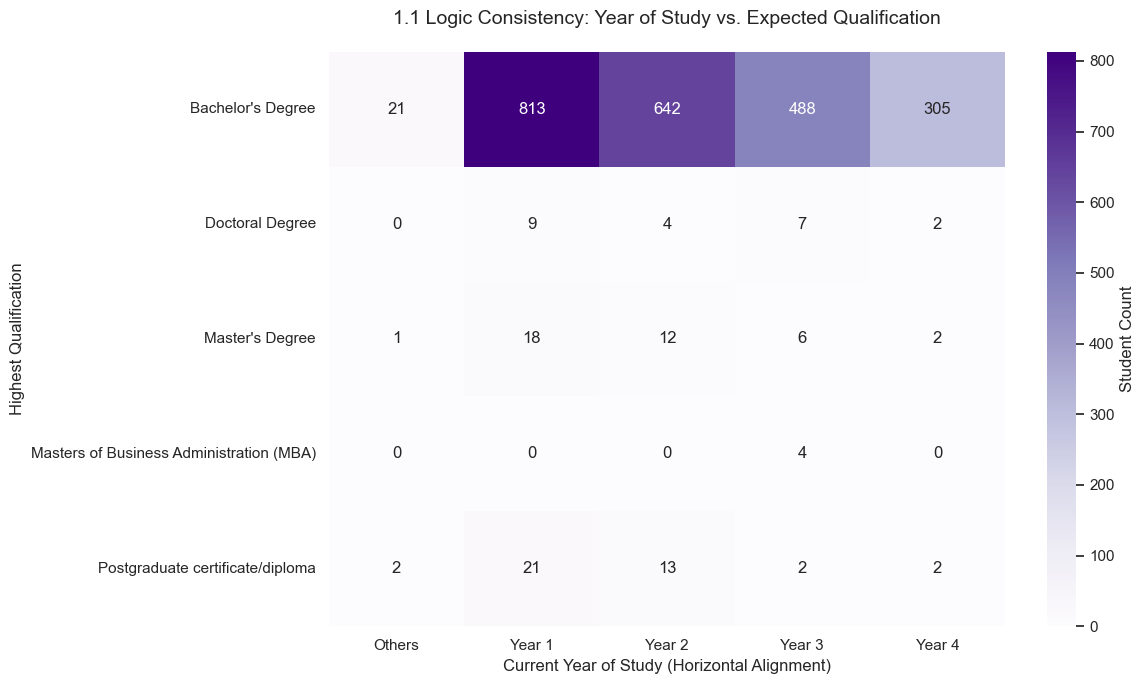

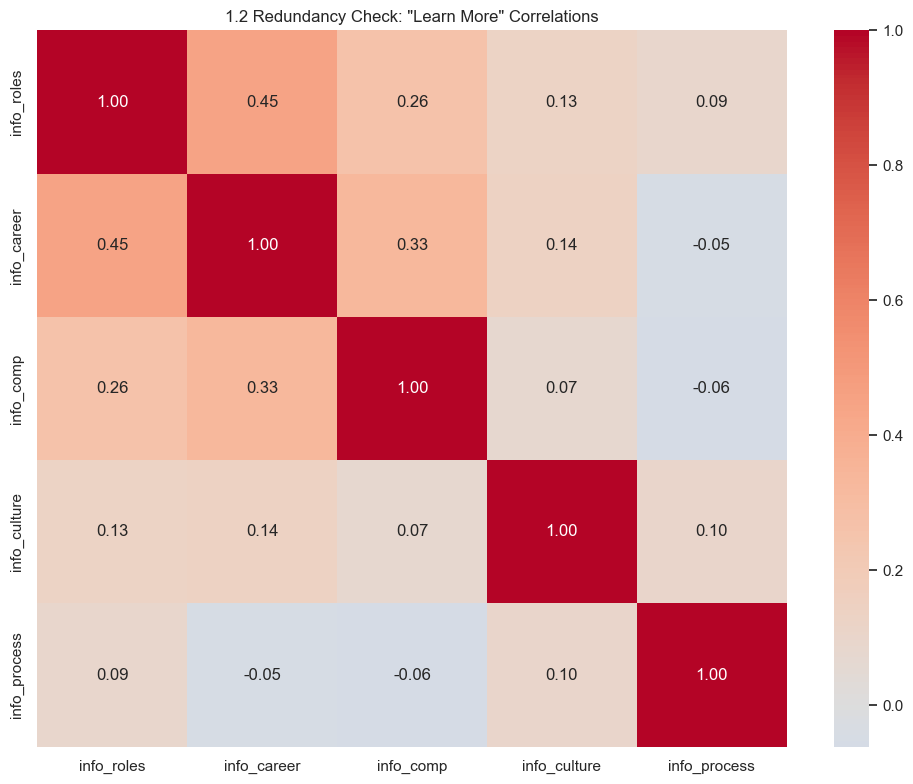

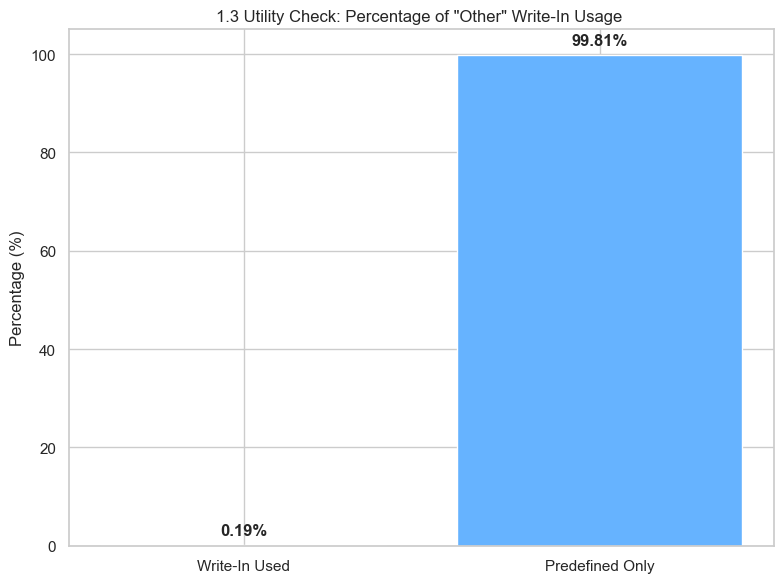

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set professional aesthetics for gradsingapore
sns.set_theme(style="whitegrid", palette="muted")

# 1.1 Logic Consistency: Year vs Qualification
plt.figure(figsize=(12, 7))

# 1. 'logic_df.T' transposes the data so Year 1, 2, 3, 4, and Others are on the horizontal (X) axis.
# 2. 'cmap="Purples"' ensures the highest counts are represented by the deepest purple.
sns.heatmap(logic_df.T, annot=True, fmt='d', cmap='Purples', cbar_kws={'label': 'Student Count'})

plt.title('1.1 Logic Consistency: Year of Study vs. Expected Qualification', fontsize=14, pad=20)
plt.xlabel('Current Year of Study (Horizontal Alignment)', fontsize=12)
plt.ylabel('Highest Qualification', fontsize=12)

# Ensure the year labels are perfectly horizontal
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

# 1.2 Redundancy: Correlation Heatmap
plt.figure(figsize=(10, 8))
# We use a diverging map to see positive/negative correlations clearly
sns.heatmap(info_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('1.2 Redundancy Check: "Learn More" Correlations')
plt.tight_layout()
plt.show()

# 1.3 Other Field Utility: Usage Bar Chart
plt.figure(figsize=(8, 6))
usage_labels = ['Write-In Used', 'Predefined Only']
usage_values = [other_usage, 100 - other_usage]
colors = ['#ff9999','#66b3ff']
plt.bar(usage_labels, usage_values, color=colors)
plt.title('1.3 Utility Check: Percentage of "Other" Write-In Usage ')
plt.ylabel('Percentage (%)')
plt.ylim(0, 105)
# Adding percentage labels on top for clarity
for i, v in enumerate(usage_values):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### CATEGORY 2: Survey Status

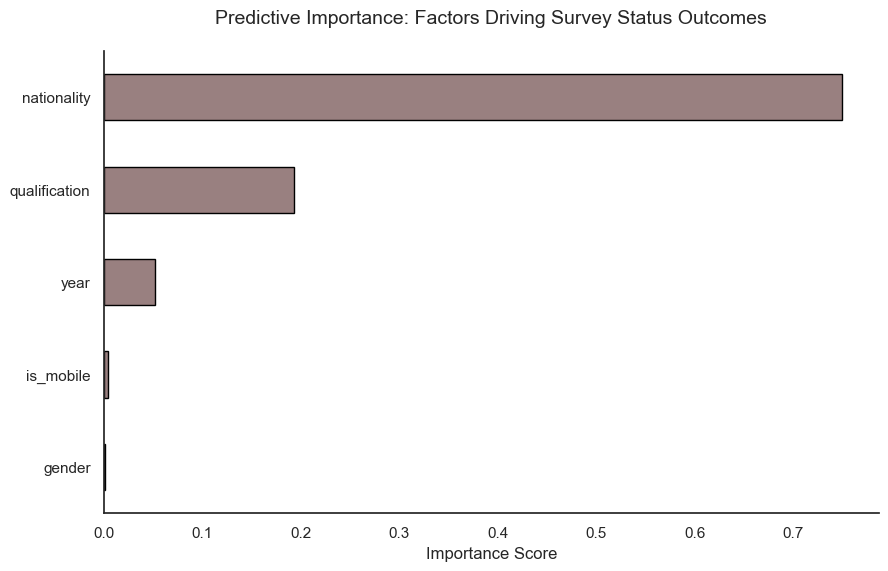

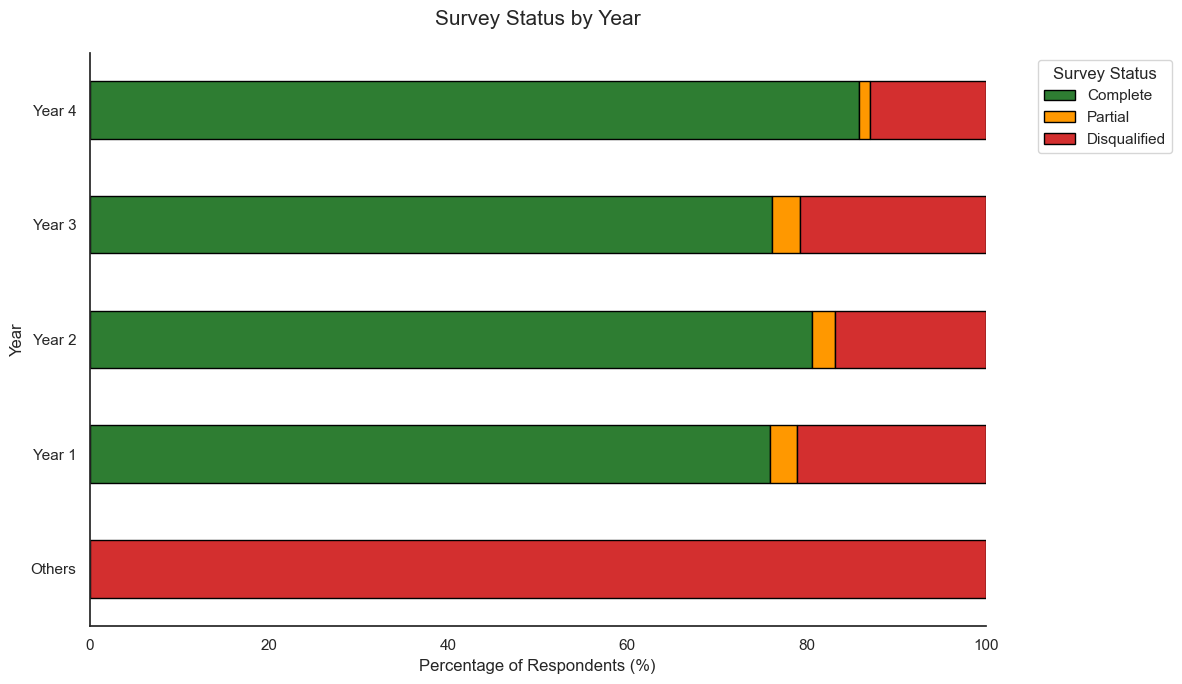

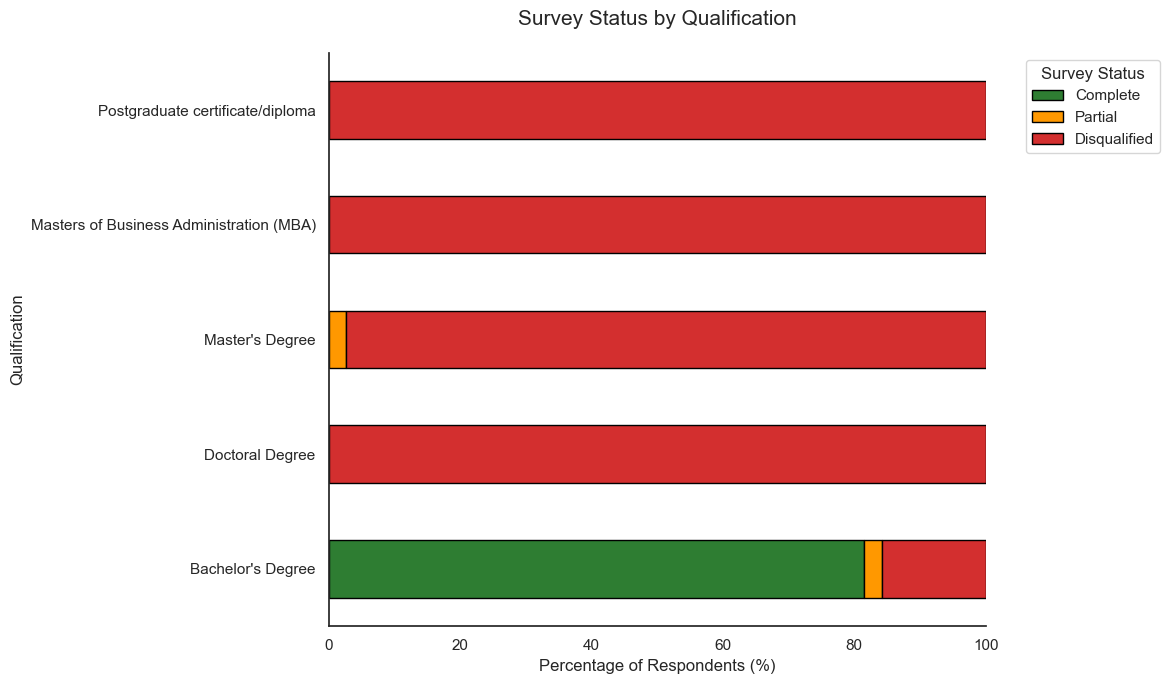

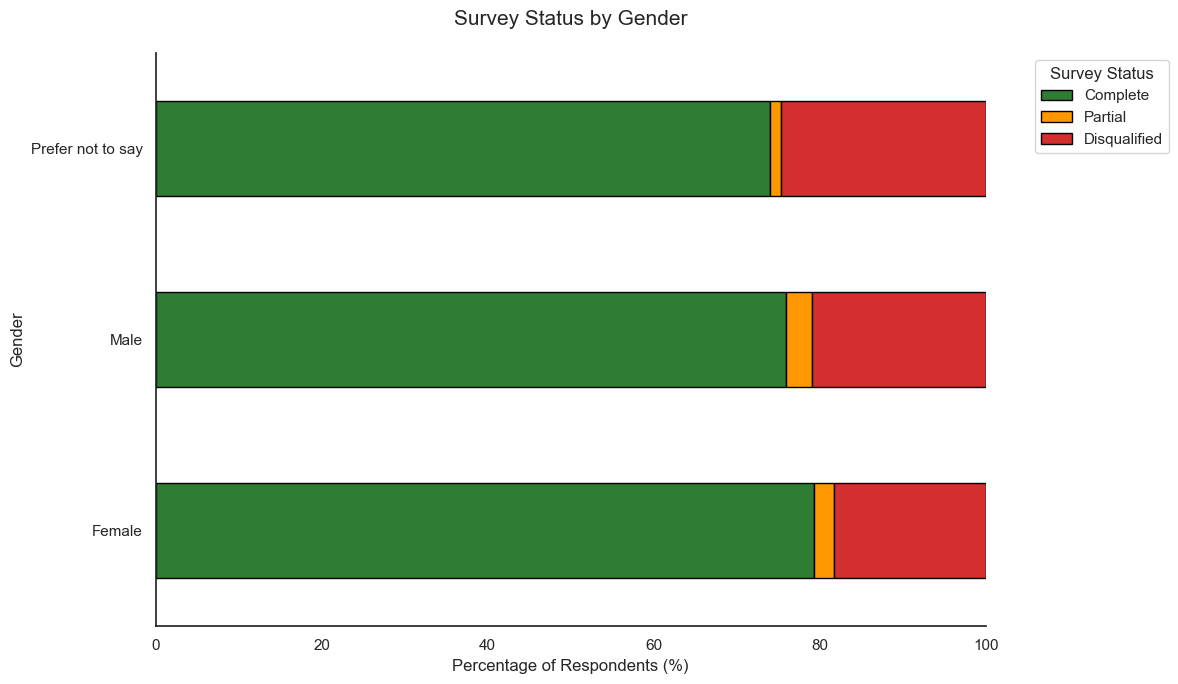

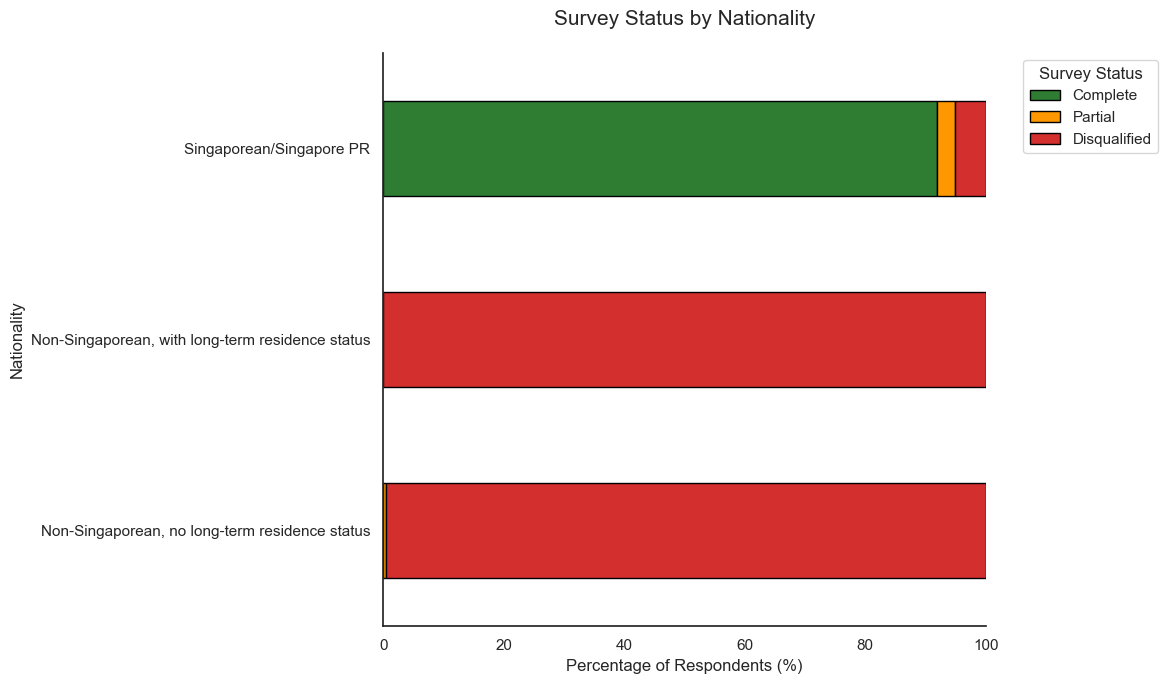

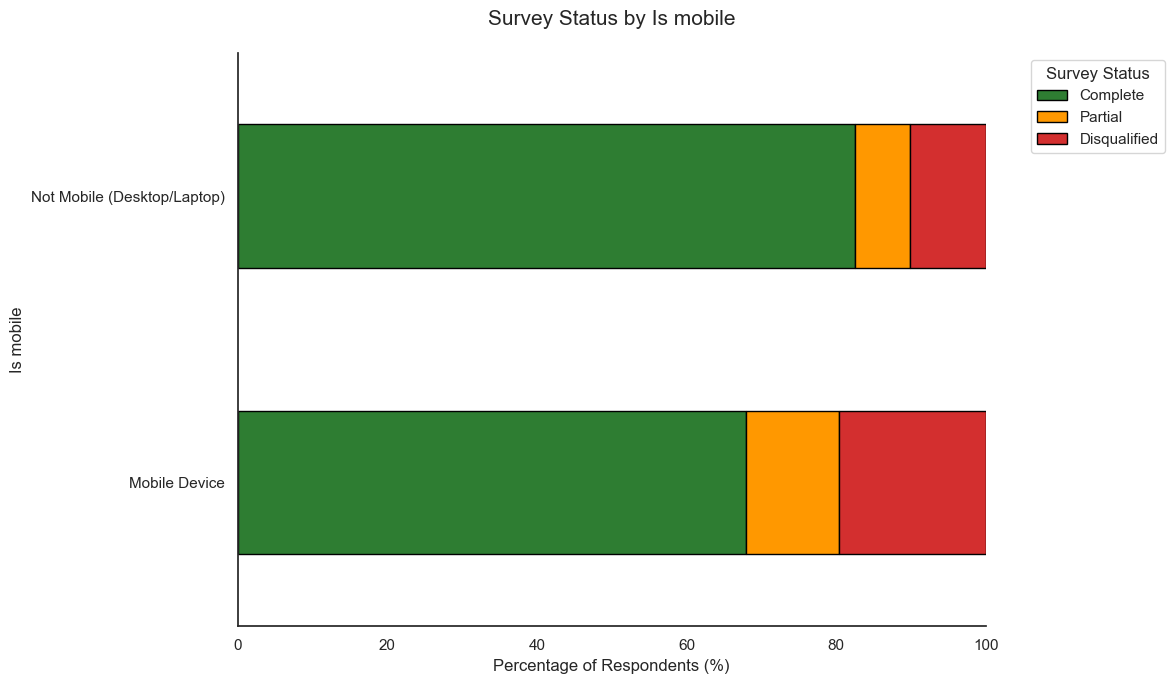

In [13]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Define the specific color mapping for survey statuses
# Complete = Green, Disqualified = Red, Partial = Orange
status_colors = {
    'Complete': '#2E7D32',      # Forest Green
    'Disqualified': '#D32F2F',  # Bright Red
    'Partial': '#FF9800'        # Vibrant Orange
}

# 1. Feature Selection
analysis_vars = ['year', 'qualification', 'gender', 'nationality', 'is_mobile']

# Map label for is_mobile for cleaner horizontal axis
df['is_mobile_label'] = df['is_mobile'].map({0: 'Not Mobile (Desktop/Laptop)', 1: 'Mobile Device'})

# 2. Predictive Power (Machine Learning Importance)
# Keep binary target for importance modeling
df['is_complete'] = (df['status'] == 'Complete').astype(int)
ml_data = df[analysis_vars + ['is_complete']].dropna()
X = ml_data[analysis_vars].copy()

for col in analysis_vars:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, ml_data['is_complete'])
importances = pd.Series(rf.feature_importances_, index=analysis_vars).sort_values(ascending=True)

# Plot 1: Importance Summary (Shows what most influences 'Status')
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#998080', edgecolor='black')
plt.title('Predictive Importance: Factors Driving Survey Status Outcomes', fontsize=14, pad=20)
plt.xlabel('Importance Score', fontsize=12)
sns.despine()
plt.show()

# 3. Status Insight Loop
for col in analysis_vars:
    plt.figure(figsize=(12, 7))
    
    # Handle the mobile label mapping
    col_to_plot = 'is_mobile_label' if col == 'is_mobile' else col
    
    # Create the cross-tabulation normalized to 100%
    # This shows the percentage breakdown of Status per category [cite: 19]
    status_dist = pd.crosstab(df[col_to_plot], df['status'], normalize='index') * 100
    
    # Ensure all three statuses exist in the columns to avoid color mapping errors
    available_statuses = [s for s in ['Complete', 'Partial', 'Disqualified'] if s in status_dist.columns]
    current_colors = [status_colors[s] for s in available_statuses]
    
    # Reorder columns so they appear in a logical order (Complete first)
    status_dist = status_dist[available_statuses]
    
    # Plotting Horizontal Stacked Bar
    status_dist.plot(kind='barh', stacked=True, ax=plt.gca(), color=current_colors, edgecolor='black')
    
    plt.title(f'Survey Status by {col.replace("_", " ").capitalize()}', fontsize=15, pad=20)
    plt.xlabel('Percentage of Respondents (%)', fontsize=12)
    plt.ylabel(col.replace("_", " ").capitalize(), fontsize=12)
    
    # Keep labels horizontal for readability
    plt.yticks(rotation=0)
    plt.xlim(0, 100)
    
    # Place legend outside
    plt.legend(title='Survey Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

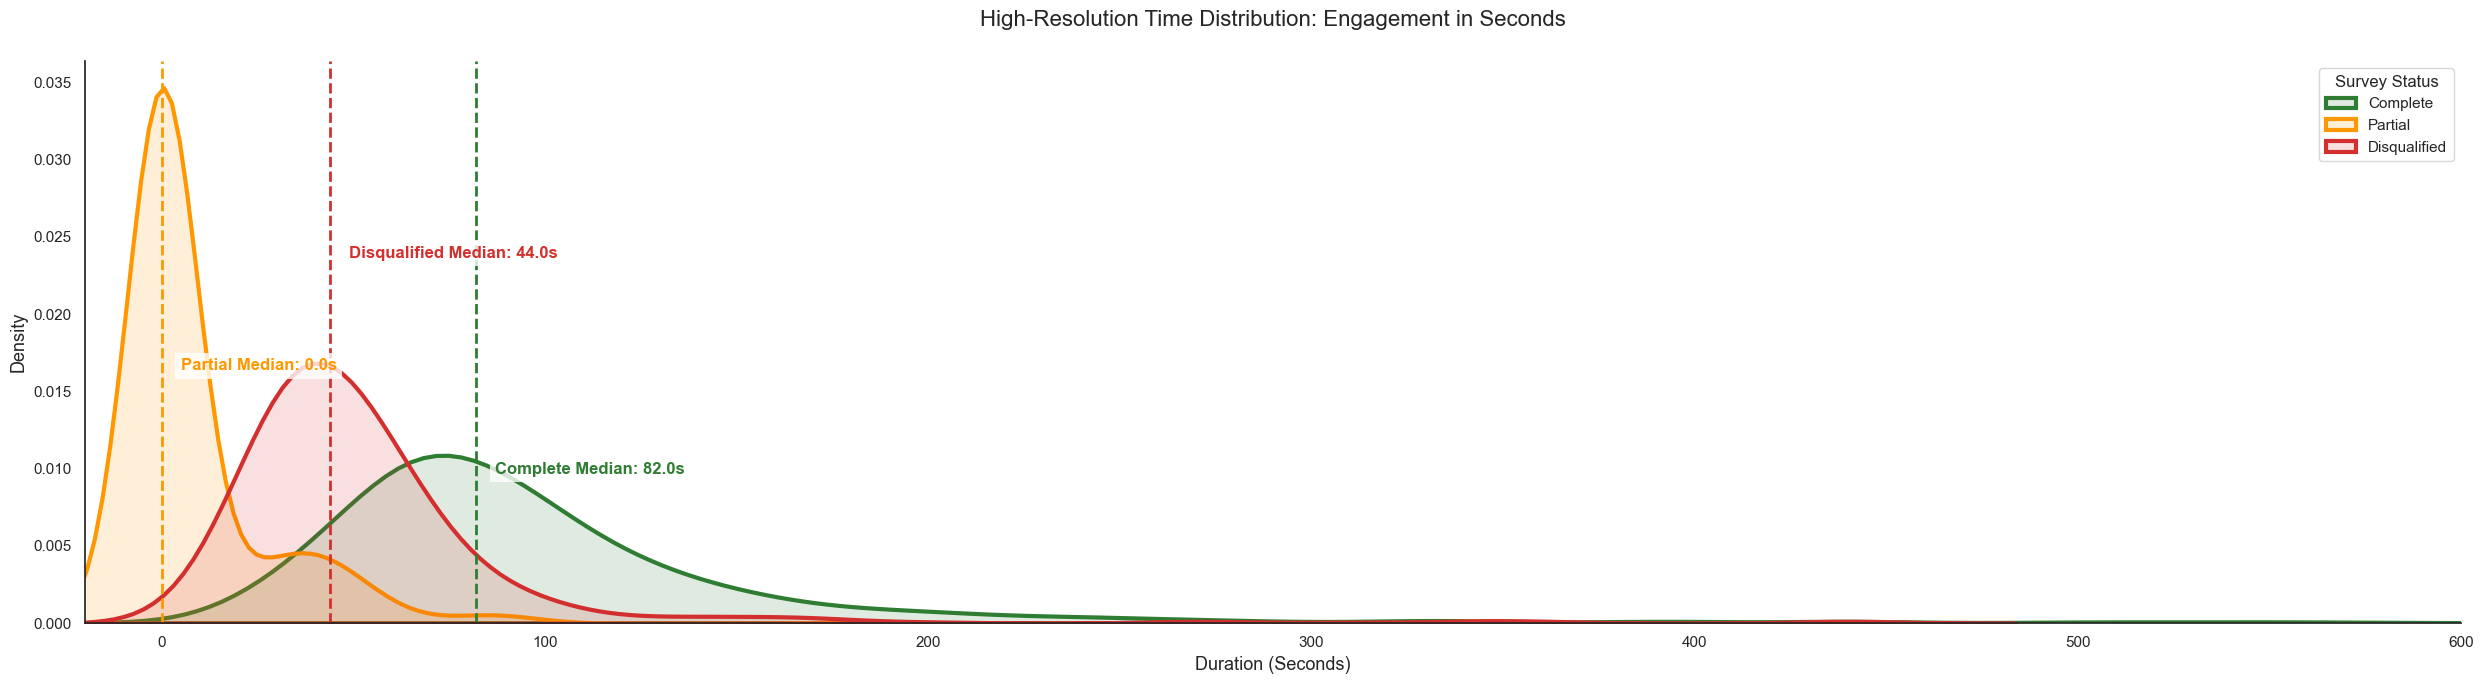

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate duration in seconds

# 2. Define Traffic Light colors
status_colors = {'Complete': '#2E7D32', 'Partial': '#FF9800', 'Disqualified': '#D32F2F'}

plt.figure(figsize=(25, 7))
sns.set_theme(style="white")

for status, color in status_colors.items():
    subset = df[(df['status'] == status) & (df['duration_sec'] <= 600)]
    
    # Line Graph (KDE)
    sns.kdeplot(subset['duration_sec'], label=status, color=color, fill=True, alpha=0.15, linewidth=3)
    
    # Median Vertical Line
    median_val = subset['duration_sec'].median()
    plt.axvline(median_val, color=color, linestyle='--', linewidth=2)
    
    # Annotate Median in Seconds
    y_pos = plt.gca().get_ylim()[1] * (0.85 if status == 'Complete' else 0.65 if status == 'Disqualified' else 0.45)
    plt.text(median_val + 5, y_pos, f'{status} Median: {median_val:.1f}s', 
             color=color, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.title('High-Resolution Time Distribution: Engagement in Seconds', fontsize=16, pad=25)
plt.xlabel('Duration (Seconds)', fontsize=13)
plt.ylabel('Density', fontsize=13)
plt.xlim(-20, 600) # Show first 10 minutes
plt.legend(title='Survey Status', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

/var/folders/mb/9y6pxy613_x_ync4yzkhl_1m0000gn/T/ipykernel_22973/1199247553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='duration_sec', y='status', data=df[df['duration_sec'] <= 600],


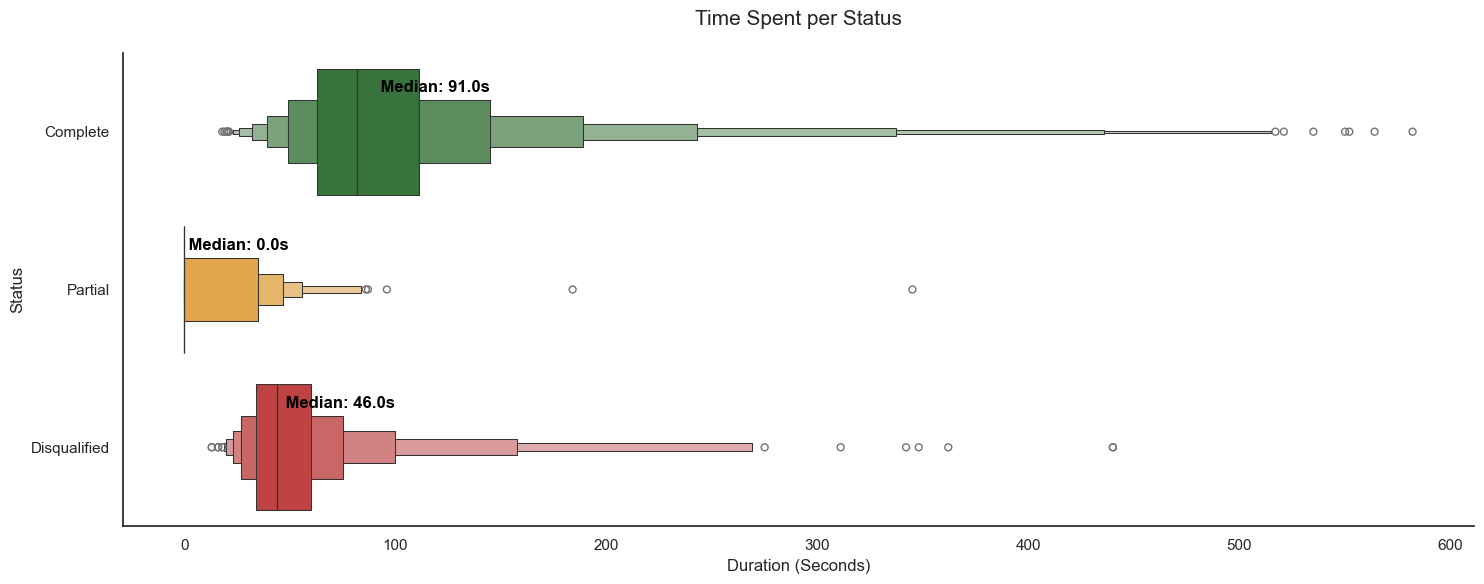

In [20]:
plt.figure(figsize=(15, 6))

# Boxen plot is great for large data and shows distribution depth
sns.boxenplot(x='duration_sec', y='status', data=df[df['duration_sec'] <= 600],
              order=['Complete', 'Partial', 'Disqualified'],
              palette=status_colors)

plt.title('Time Spent per Status', fontsize=15, pad=20)
plt.xlabel('Duration (Seconds)', fontsize=12)
plt.ylabel('Status', fontsize=12)

# Add median text labels
for i, status in enumerate(['Complete', 'Partial', 'Disqualified']):
    med = df[df['status'] == status]['duration_sec'].median()
    plt.text(med, i - 0.25, f' Median: {med:.1f}s', fontweight='bold', color='black')

sns.despine()
plt.tight_layout()
plt.show()